In [1]:
from sklearn import datasets

iris = datasets.load_iris()
print(iris.target_names)
print(iris.target)
print(iris.data[:5])
print(iris.feature_names)


['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [2]:
iris.data.shape

(150, 4)

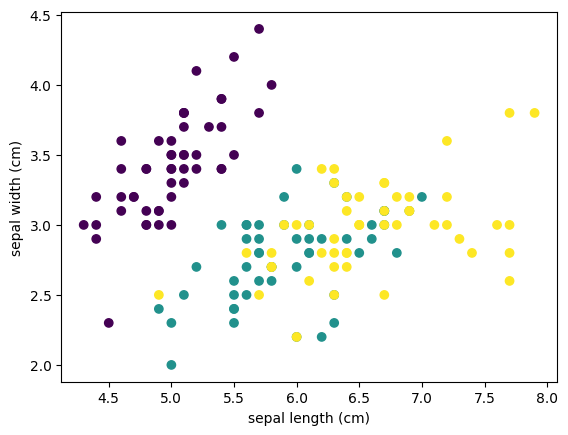

In [3]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots()
axes.scatter(iris.data[:,0],iris.data[:,1],c=iris.target)
axes.set_xlabel(iris.feature_names[0])
axes.set_ylabel(iris.feature_names[1])
plt.show()

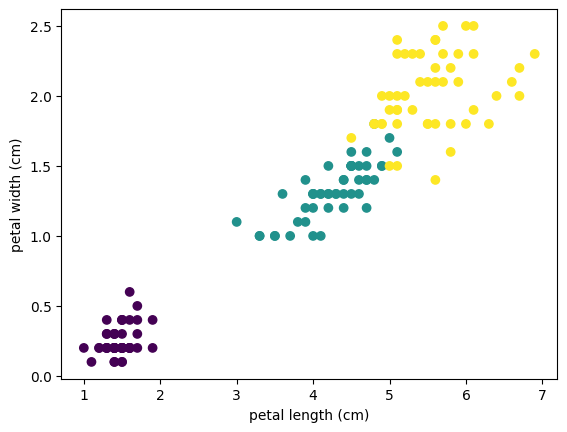

In [4]:
fig,axes=plt.subplots()
axes.scatter(iris.data[:,2],iris.data[:,3],c=iris.target)
axes.set_xlabel(iris.feature_names[2])
axes.set_ylabel(iris.feature_names[3])
plt.show()

In [5]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='loss', mode="min", patience=5)

In [8]:
import tensorflow as tf
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.Input(shape=[iris.data.shape[1]]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

opt = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=opt,
              metrics=["accuracy"])

Xtrain, X_test, ytrain, y_test = train_test_split(
    iris.data, iris.target , test_size=0.2, random_state=42)

model.fit(   Xtrain,ytrain,
            epochs=40,
            callbacks=[early_stopping]
        )

predicciones = model.predict(X_test)
predicciones=tf.argmax(predicciones,axis=1)
informe=classification_report(y_test,predicciones,target_names=iris.target_names)
print(informe)



Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5017 - loss: 1.1737
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7163 - loss: 0.6607
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7202 - loss: 0.4853 
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9792 - loss: 0.3005
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9304 - loss: 0.2480
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9583 - loss: 0.1821 
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9912 - loss: 0.1148
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9708 - loss: 0.0964
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9590 - loss: 0.1231
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9623 - loss: 0.1013
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9879 - loss: 0.0628
Epoch 12/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9879 - loss: 0.0585

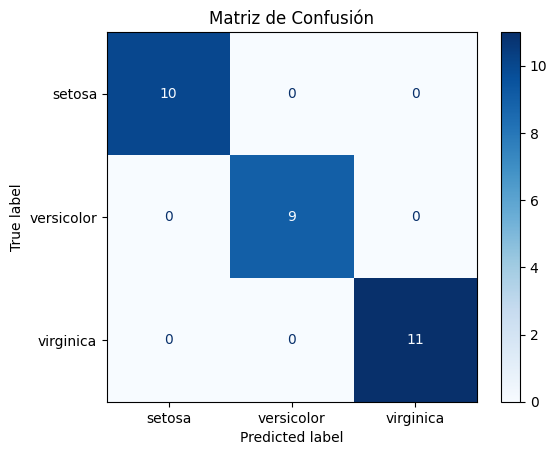

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(iris.target_names))
disp.plot(cmap=plt.cm.Blues)


plt.title("Matriz de Confusión")
plt.show()